# مدار المركبة المدارية الشمسية حول الشمس خلال عام 2025 


**إعداد:** د. عمرو حمادة  
**المرصد الشمسي الوطني (National Solar Observatory — NSO)**


---


## البيانات والبرمجيات

**Trajectory:** JPL Horizons  
**Solar observations:** ESA/NASA Solar Orbiter — EUI/FSI 174 Å  
**Archive:** Solar Orbiter Archive (SOAR)

**Software:** SunPy, sunpy-soar, Astropy, NumPy, Matplotlib, Pillow, and ImageIO

---

## روابط ومراجع

- Solar Orbiter mission:  
  https://www.esa.int/Science_Exploration/Space_Science/Solar_Orbiter

- Solar Orbiter Archive (SOAR):  
  https://soar.esac.esa.int/

- SunPy coordinate documentation:  
  https://docs.sunpy.org/

- JPL Horizons:  
  https://ssd.jpl.nasa.gov/horizons/

---

In [1]:
from pathlib import Path
# ============================================================
# 0) Install packages inside the same running kernel
# ============================================================

import sys
import subprocess

packages = [
    'sunpy[map,net]',
    'sunpy-soar==1.11.1',   # compatible with Python 3.10
    'matplotlib',
    'numpy',
    'astropy',
    'pillow',
    'imageio',
    'imageio-ffmpeg',
    'requests-toolbelt',
]

print("Python executable:")
print(sys.executable)
print()

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', *packages])

print("\nInstallation complete.")
print("If this was the first installation of sunpy-soar, do: Restart Kernel -> Run All")

Python executable:
/Users/Amr/miniconda3/bin/python




[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



Installation complete.
If this was the first installation of sunpy-soar, do: Restart Kernel -> Run All


## 1) الإعدادات

In [2]:
from pathlib import Path

# ============================================================
# User settings
# ============================================================

YEAR = 2025

# Smooth video cadence:
FRAME_CADENCE_DAYS = 5      # orbit animation cadence
EUI_CADENCE_DAYS   = 15     # EUI update cadence

FPS = 4   # 2x slower than the original 8 FPS

# Search windows for EUI
EUI_SEARCH_WINDOW_DAYS = [2, 5, 10]
EUI_LEVELS = [2, 1]

# EUI contrast
EUI_LOW_PERCENTILE  = 1.0
EUI_HIGH_PERCENTILE = 99.7
EUI_GAMMA = 0.55

# Orbit sampling for the background trajectory line
ORBIT_LINE_STEP = "1d"

# Figure / video layout
FIGSIZE = (10, 7.5)
DPI = 160   # 10 x 7.5 inch figure -> 1600 x 1200 px

# Size and offset of the EUI inset in AU
INSET_SIZE_AU   = 0.22
INSET_OFFSET_AU = 0.18

# Output names
OUT_MP4 = f"Solar_Orbiter_{YEAR}_orbit_EUI.mp4"
OUT_GIF = f"Solar_Orbiter_{YEAR}_orbit_EUI.gif"

# Cache folders
BASE_DIR = Path.cwd().resolve()
CACHE_DIR = BASE_DIR / "cache_eui"
FRAMES_DIR = BASE_DIR / "frames_solar_orbiter_video"

print("Year:", YEAR)
print("Frame cadence:", FRAME_CADENCE_DAYS, "days")
print("EUI cadence:", EUI_CADENCE_DAYS, "days")

print("Working directory:", BASE_DIR)
print("EUI cache directory:", CACHE_DIR)
print("Frames directory:", FRAMES_DIR)


Year: 2025
Frame cadence: 5 days
EUI cadence: 15 days
Working directory: /Users/Amr/Downloads/مقالي/notebook/SO/SO
EUI cache directory: /Users/Amr/Downloads/مقالي/notebook/SO/SO/cache_eui
Frames directory: /Users/Amr/Downloads/مقالي/notebook/SO/SO/frames_solar_orbiter_video


## 2) تحميل الدوال والمكتبات

In [3]:
from pathlib import Path
import shutil
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import imageio.v2 as imageio

import astropy.units as u
from astropy.time import Time, TimeDelta

import sunpy
import sunpy.map
import sunpy_soar  # registers SOAR with Fido

from sunpy.coordinates import (
    get_body_heliographic_stonyhurst,
    get_horizons_coord,
)
from sunpy.net import Fido
from sunpy.net import attrs as a

print("SunPy:", sunpy.__version__)
print("sunpy-soar:", getattr(sunpy_soar, "__version__", "unknown"))

if not hasattr(a, "soar") or not hasattr(a.soar, "Product"):
    raise RuntimeError("SOAR client not registered. Restart Kernel and Run All.")

SunPy: 6.0.6
sunpy-soar: 1.11.1


## 3) التوقيت

In [4]:
# ============================================================
# Build time grids
# ============================================================

start_time = Time(f"{YEAR}-01-01T00:00:00")
end_time   = Time(f"{YEAR}-12-31T00:00:00")

def build_time_grid(start, end, step_days):
    times = []
    t = start
    while t <= end:
        times.append(t)
        t = t + TimeDelta(step_days * u.day)
    if times[-1] < end:
        times.append(end)
    return times

frame_times = build_time_grid(start_time, end_time, FRAME_CADENCE_DAYS)
eui_times   = build_time_grid(start_time, end_time, EUI_CADENCE_DAYS)

print("Number of video frames:", len(frame_times))
print("Number of EUI query dates:", len(eui_times))
print("Approximate video duration:", len(frame_times) / FPS, "seconds")

Number of video frames: 74
Number of EUI query dates: 26
Approximate video duration: 18.5 seconds


## 4) المسار


In [5]:
# ============================================================
# Fetch Solar Orbiter trajectory and frame positions
# ============================================================

earth_ref = get_body_heliographic_stonyhurst("Earth", start_time)

orbit_request = {
    "start": start_time,
    "stop": end_time,
    "step": ORBIT_LINE_STEP,
}

print("Fetching background orbit line from JPL Horizons...")
solo_orbit_hgs = get_horizons_coord("Solar Orbiter", orbit_request)
solo_orbit = solo_orbit_hgs.transform_to(earth_ref)

print("Fetching Solar Orbiter positions for frame dates...")
solo_frame_positions_hgs = [get_horizons_coord("Solar Orbiter", t) for t in frame_times]
solo_frame_positions = [c.transform_to(earth_ref) for c in solo_frame_positions_hgs]

# Optional Earth positions as a subtle geometric reference
earth_positions = [get_body_heliographic_stonyhurst("Earth", t).transform_to(earth_ref) for t in frame_times]

print("Done.")

Fetching background orbit line from JPL Horizons...


2026-09-02 22:16:41 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
Fetching Solar Orbiter positions for frame dates...


2026-09-02 22:16:41 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]


...

INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]


2026-09-02 22:17:00 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]


2026-09-02 22:17:00 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
Done.


## 5) الإحداثيات

In [6]:
# ============================================================
# Coordinate helpers
# ============================================================

def hgs_to_xy(coord):
    lon = coord.lon.to_value(u.rad)
    lat = coord.lat.to_value(u.rad)
    r   = coord.radius.to_value(u.AU)

    x = r * np.cos(lat) * np.cos(lon)
    y = r * np.cos(lat) * np.sin(lon)

    return np.asarray(x), np.asarray(y)

x_orbit, y_orbit = hgs_to_xy(solo_orbit)
x_orbit = np.asarray(x_orbit, dtype=float)
y_orbit = np.asarray(y_orbit, dtype=float)

frame_xy = []
for c in solo_frame_positions:
    x, y = hgs_to_xy(c)
    frame_xy.append((float(np.atleast_1d(x)[0]), float(np.atleast_1d(y)[0])))

earth_xy = []
for c in earth_positions:
    x, y = hgs_to_xy(c)
    earth_xy.append((float(np.atleast_1d(x)[0]), float(np.atleast_1d(y)[0])))

def angular_separation_from_sun(coord1, coord2):
    lon1 = coord1.lon.to_value(u.rad)
    lat1 = coord1.lat.to_value(u.rad)
    lon2 = coord2.lon.to_value(u.rad)
    lat2 = coord2.lat.to_value(u.rad)

    v1 = np.array([np.cos(lat1)*np.cos(lon1), np.cos(lat1)*np.sin(lon1), np.sin(lat1)])
    v2 = np.array([np.cos(lat2)*np.cos(lon2), np.cos(lat2)*np.sin(lon2), np.sin(lat2)])

    ang = np.degrees(np.arccos(np.clip(np.dot(v1, v2), -1.0, 1.0)))
    return float(ang)


# ============================================================
# SOAR-only EUI search helper
# ============================================================

cache_dir = Path(CACHE_DIR).resolve()
cache_dir.mkdir(parents=True, exist_ok=True)
print("Using EUI cache:", cache_dir)

def fetch_nearest_eui_fsi174(target_time, search_windows_days=(2, 5, 10), levels=(2, 1)):
    product = a.soar.Product("EUI-FSI174-IMAGE")
    t_center = Time(target_time)

    for level in levels:
        for dd in search_windows_days:
            t1 = t_center - dd * u.day
            t2 = t_center + dd * u.day

            print(f"Searching SOAR: {t_center.isot} | Level {level} | ±{dd} d")

            query = (
                a.Time(t1, t2)
                & a.Instrument("EUI")
                & a.Level(level)
                & product
            )

            results = Fido.search(query)

            if "soar" not in results.keys():
                continue

            soar = results["soar"]

            if len(soar) == 0:
                continue

            starts = Time(soar["Start time"])
            idx = int(np.argmin(np.abs((starts - t_center).to_value(u.s))))
            chosen = soar[idx]

            downloaded = Fido.fetch(chosen, path=str(cache_dir / "{file}"))
            if len(downloaded) > 0:
                return str(downloaded[0]), level

    return None, None

Using EUI cache: /Users/Amr/Downloads/مقالي/notebook/SO/SO/cache_eui


## 6) تحميل الصور


In [7]:
# ============================================================
# Download or locate cached EUI files
# ============================================================

eui_files = {}
last_good_file = None

for t in eui_times:
    key = t.strftime("%Y-%m-%d")

    fpath, lvl = fetch_nearest_eui_fsi174(
        t,
        search_windows_days=EUI_SEARCH_WINDOW_DAYS,
        levels=EUI_LEVELS
    )

    if fpath is None:
        print(f"No EUI found for {key}; reusing previous image if available.")
        eui_files[key] = {"file": last_good_file, "level": None, "time": t}
    else:
        eui_files[key] = {"file": fpath, "level": lvl, "time": t}
        last_good_file = fpath

# Map every frame date to the nearest EUI date
eui_date_strings = [t.strftime("%Y-%m-%d") for t in eui_times]

frame_to_eui_key = []
for ft in frame_times:
    idx = int(np.argmin([abs((ft - et).to_value(u.day)) for et in eui_times]))
    frame_to_eui_key.append(eui_date_strings[idx])

print("Cached / mapped EUI dates complete.")

Searching SOAR: 2025-01-01T00:00:00.000 | Level 2 | ±2 d


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L2_eui-fsi174-image_20250101T000055251_V02.fits:   0%|          | 0.00/3.83M [00:00<?, ?B/s]

Searching SOAR: 2025-01-16T00:00:00.000 | Level 2 | ±2 d


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

solo_L2_eui-fsi174-image_20251227T000055190_V01.fits:   0%|          | 0.00/3.86M [00:00<?, ?B/s]

Searching SOAR: 2025-12-31T00:00:00.000 | Level 2 | ±2 d


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L2_eui-fsi174-image_20251231T000055206_V01.fits:   0%|          | 0.00/4.15M [00:00<?, ?B/s]

Cached / mapped EUI dates complete.


## 7) تحويل صور الشمس

Prepared cropped EUI images: 26


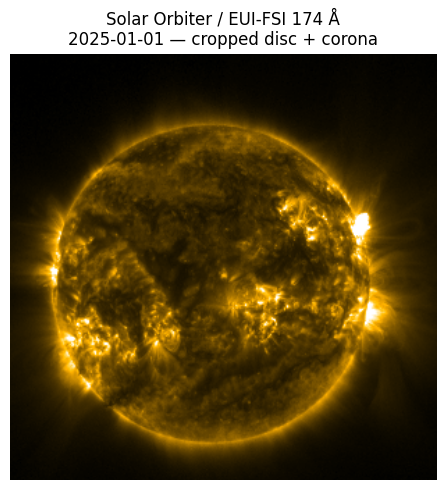

In [8]:
# ============================================================
# EUI image preparation
# Crop around the solar disc + corona BEFORE any preview/frame
# ============================================================

# Amount of corona retained around the visible solar radius:
# 1.0 = disc only
# 1.2 = disc + a little corona
# 1.4 = wider corona
EUI_CORONA_FACTOR = 1.35

# Reduce the cropped image if it is still large
EUI_MAX_OUTPUT_SIZE = 420   # pixels

def prepare_eui_rgba(file_path):
    """
    Read a Solar Orbiter/EUI image, crop around the solar disc
    while retaining part of the corona, enhance contrast, and
    return an RGBA image ready for display.

    Returns
    -------
    rgba : ndarray or None
        Cropped display-ready RGBA image.
    label : str
        Observation date.
    """
    if file_path is None:
        return None, "No EUI image"

    m = sunpy.map.Map(file_path)

    data = np.asarray(m.data, dtype=float)
    good = np.isfinite(data)

    if not np.any(good):
        return None, "Invalid EUI image"

    # --------------------------------------------------------
    # Solar-disc center in pixel coordinates
    # --------------------------------------------------------
    cx_pix, cy_pix = m.world_to_pixel(m.reference_coordinate)
    cx = float(cx_pix.value)
    cy = float(cy_pix.value)

    # --------------------------------------------------------
    # Apparent solar radius in pixels
    # --------------------------------------------------------
    sx = np.abs(m.scale.axis1.to_value(u.arcsec / u.pix))
    sy = np.abs(m.scale.axis2.to_value(u.arcsec / u.pix))

    rsun_arcsec = m.rsun_obs.to_value(u.arcsec)

    rx = rsun_arcsec / sx
    ry = rsun_arcsec / sy

    # Keep the disc plus a controlled amount of corona
    half_width  = int(np.ceil(EUI_CORONA_FACTOR * rx))
    half_height = int(np.ceil(EUI_CORONA_FACTOR * ry))

    # --------------------------------------------------------
    # Crop limits
    # --------------------------------------------------------
    ny, nx = data.shape

    x0 = max(0, int(np.floor(cx - half_width)))
    x1 = min(nx, int(np.ceil(cx + half_width)))
    y0 = max(0, int(np.floor(cy - half_height)))
    y1 = min(ny, int(np.ceil(cy + half_height)))

    cropped = data[y0:y1, x0:x1]
    cropped_good = np.isfinite(cropped)

    if not np.any(cropped_good):
        return None, "Invalid cropped EUI image"

    # --------------------------------------------------------
    # Contrast enhancement on the CROPPED image only
    # --------------------------------------------------------
    vmin = np.nanpercentile(
        cropped[cropped_good],
        EUI_LOW_PERCENTILE
    )
    vmax = np.nanpercentile(
        cropped[cropped_good],
        EUI_HIGH_PERCENTILE
    )

    scaled = np.clip(
        (cropped - vmin) / (vmax - vmin),
        0,
        1
    )
    scaled = scaled ** EUI_GAMMA

    cmap = m.plot_settings.get(
        "cmap",
        plt.get_cmap("inferno")
    )
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)

    rgba = cmap(scaled)
    rgba[..., 3] = np.where(
        cropped_good,
        1.0,
        0.0
    )

    # --------------------------------------------------------
    # Downsample only AFTER cropping
    # --------------------------------------------------------
    h, w = rgba.shape[:2]
    max_dim = max(h, w)

    if max_dim > EUI_MAX_OUTPUT_SIZE:
        step = int(
            np.ceil(
                max_dim / EUI_MAX_OUTPUT_SIZE
            )
        )
        rgba = rgba[::step, ::step, :]

    label = m.date.strftime("%Y-%m-%d")
    return rgba, label


# Build the display cache using the cropped images
prepared_eui = {}

for key, info in eui_files.items():
    rgba, label = prepare_eui_rgba(
        info["file"]
    )

    prepared_eui[key] = {
        "rgba": rgba,
        "label": label,
        "file": info["file"]
    }

print(
    "Prepared cropped EUI images:",
    len(prepared_eui)
)

# ------------------------------------------------------------
# FIRST EUI DISPLAY: show the first available CROPPED image
# ------------------------------------------------------------
first_preview_key = next(
    (
        key for key in eui_date_strings
        if prepared_eui.get(key, {}).get("rgba") is not None
    ),
    None
)

if first_preview_key is not None:
    first_preview = prepared_eui[first_preview_key]

    plt.figure(figsize=(5, 5))
    plt.imshow(
        first_preview["rgba"],
        origin="lower",
        interpolation="bilinear"
    )
    plt.title(
        f"Solar Orbiter / EUI-FSI 174 Å\n"
        f"{first_preview['label']} — cropped disc + corona"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No EUI image is available for the first cropped preview.")


## 8) إطارات الفيديو


In [9]:
# ============================================================
# Frame rendering
# ============================================================

frames_dir = Path(FRAMES_DIR).resolve()
if frames_dir.exists():
    shutil.rmtree(frames_dir)
frames_dir.mkdir(parents=True, exist_ok=True)
print("Rendering frames into:", frames_dir)

# Figure limits
tmp_x = list(x_orbit) + [xy[0] for xy in frame_xy]
tmp_y = list(y_orbit) + [xy[1] for xy in frame_xy]
LIM = max(
    1.10,
    np.max(np.abs(tmp_x)) + 0.25,
    np.max(np.abs(tmp_y)) + 0.25
)

def draw_one_frame(i):
    t = frame_times[i]
    xs, ys = frame_xy[i]
    xe, ye = earth_xy[i]

    sep = angular_separation_from_sun(
        solo_frame_positions[i],
        earth_positions[i]
    )

    eui_key = frame_to_eui_key[i]
    eui_rgba = prepared_eui[eui_key]["rgba"]
    eui_label = prepared_eui[eui_key]["label"]

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    # 1 AU reference circle
    th = np.linspace(0, 2*np.pi, 500)
    ax.plot(np.cos(th), np.sin(th), ":", lw=1.0, alpha=0.25, color="0.5")

    # Orbit line
    ax.plot(x_orbit, y_orbit, lw=2.5, color="tab:red", zorder=2, label="Solar Orbiter orbit")

    # Sun
    ax.scatter([0], [0], s=500, color="gold", edgecolor="darkorange", lw=1.2, zorder=10)
    ax.text(0, -0.07, "Sun", ha="center", va="top", fontsize=12, weight="bold")

    # Optional Earth reference
    ax.scatter([xe], [ye], s=70, color="royalblue", edgecolor="navy", lw=0.8, zorder=8)
    ax.text(xe, ye + 0.045, "Earth", ha="center", va="bottom", fontsize=10)

    # Line of sight from Sun to Solar Orbiter
    ax.plot([0, xs], [0, ys], "--", lw=1.4, color="tab:red", alpha=0.7, zorder=1)
    ax.plot([0, xe], [0, ye], "--", lw=1.0, color="tab:blue", alpha=0.45, zorder=1)

    # Current spacecraft location
    ax.scatter([xs], [ys], s=90, marker="D", color="crimson", edgecolor="darkred", lw=0.8, zorder=12)
    ax.text(xs, ys - 0.05, "Solar Orbiter", ha="center", va="top", fontsize=10.5, weight="bold")

    # Past positions up to current time
    trail_x = [frame_xy[j][0] for j in range(i + 1)]
    trail_y = [frame_xy[j][1] for j in range(i + 1)]
    ax.plot(trail_x, trail_y, lw=1.2, color="crimson", alpha=0.45, zorder=3)

    # Small EUI inset next to the spacecraft
    rxy = np.hypot(xs, ys)
    if rxy > 0:
        ux = xs / rxy
        uy = ys / rxy
    else:
        ux, uy = 1.0, 0.0

    x0 = xs + INSET_OFFSET_AU * ux - INSET_SIZE_AU / 2
    x1 = xs + INSET_OFFSET_AU * ux + INSET_SIZE_AU / 2
    y0 = ys + INSET_OFFSET_AU * uy - INSET_SIZE_AU / 2
    y1 = ys + INSET_OFFSET_AU * uy + INSET_SIZE_AU / 2

    if eui_rgba is not None:
        ax.imshow(
            eui_rgba,
            origin="lower",
            extent=[x0, x1, y0, y1],
            interpolation="bilinear",
            zorder=20,
        )

    rect = Rectangle((x0, y0), INSET_SIZE_AU, INSET_SIZE_AU,
                     fill=False, lw=1.2, ec="0.15", zorder=21)
    ax.add_patch(rect)

    # Connector
    ax.plot([xs, (x0 + x1) / 2], [ys, (y0 + y1) / 2], "-", lw=0.9, color="0.25", alpha=0.8, zorder=18)

    # EUI label
    ax.text((x0 + x1)/2, y1 + 0.035, f"EUI / FSI 174 Å\n{eui_label}",
            ha="center", va="bottom", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.7", alpha=0.9),
            zorder=22)

    # Info box
    r_au = solo_frame_positions[i].radius.to_value(u.AU)
    ax.text(
        0.02, 0.02,
        f"Date: {t.strftime('%Y-%m-%d')}\n"
        f"Distance from Sun: {r_au:.3f} AU\n"
        f"Earth–SO angular separation: {sep:.1f}°",
        transform=ax.transAxes,
        ha="left", va="bottom", fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.30", fc="white", ec="0.6", alpha=0.92)
    )

    ax.set_title(f"Solar Orbiter around the Sun during {YEAR}", fontsize=15, pad=10)
    ax.set_xlabel("Heliocentric X [AU]")
    ax.set_ylabel("Heliocentric Y [AU]")

    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.15, lw=0.7)

    plt.tight_layout()

    out = frames_dir / f"frame_{i:03d}.png"
    # IMPORTANT:
    # Do NOT use bbox_inches="tight" for movie frames.
    # Every frame must keep exactly the same pixel dimensions.
    fig.savefig(
        out,
        dpi=DPI,
        facecolor="white"
    )

    # Safety check: fail immediately if the PNG was not written.
    if not out.exists():
        plt.close(fig)
        raise RuntimeError(
            f"Frame was not saved: {out}"
        )
    plt.close(fig)
    return out

for i in range(len(frame_times)):
    if i % 5 == 0 or i == len(frame_times) - 1:
        print(f"Rendering frame {i+1}/{len(frame_times)}")
    draw_one_frame(i)

saved_frames = sorted(frames_dir.glob("frame_*.png"))

print("All frames rendered to:", frames_dir)
print("Number of PNG frames actually saved:", len(saved_frames))

if len(saved_frames) != len(frame_times):
    raise RuntimeError(
        f"Expected {len(frame_times)} PNG frames, "
        f"but found {len(saved_frames)} in {frames_dir}"
    )

Rendering frames into: /Users/Amr/Downloads/مقالي/notebook/SO/SO/frames_solar_orbiter_video
Rendering frame 1/74
Rendering frame 6/74
Rendering frame 11/74
Rendering frame 16/74
Rendering frame 21/74
Rendering frame 26/74
Rendering frame 31/74
Rendering frame 36/74
Rendering frame 41/74
Rendering frame 46/74
Rendering frame 51/74
Rendering frame 56/74
Rendering frame 61/74
Rendering frame 66/74
Rendering frame 71/74
Rendering frame 74/74
All frames rendered to: /Users/Amr/Downloads/مقالي/notebook/SO/SO/frames_solar_orbiter_video
Number of PNG frames actually saved: 74


## 9) بناء الفيديو و الصورة المتحركة GIF

In [10]:
# ============================================================
# Build MP4 and GIF — self-healing fixed-size version
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np
import imageio.v2 as imageio

# Always resolve the exact folder being used
frames_dir = Path(FRAMES_DIR).resolve()

print("Current working directory:")
print(Path.cwd().resolve())

print("\nLooking for frames in:")
print(frames_dir)

frame_paths = sorted(frames_dir.glob("frame_*.png"))

# ------------------------------------------------------------
# If no frames exist, generate them automatically
# ------------------------------------------------------------

if not frame_paths:
    print("\nNo PNG frames found.")
    print("Generating all video frames now ...")

    frames_dir.mkdir(parents=True, exist_ok=True)

    for i in range(len(frame_times)):
        if i % 5 == 0 or i == len(frame_times) - 1:
            print(
                f"Rendering frame {i+1}/{len(frame_times)}"
            )

        draw_one_frame(i)

    frame_paths = sorted(
        frames_dir.glob("frame_*.png")
    )

# Final safety check
if not frame_paths:
    raise RuntimeError(
        "Frame generation finished, but no PNG files were found.\n"
        f"Expected folder: {frames_dir}\n"
        "Run the frame-rendering cell above once and inspect any error it reports."
    )

print(
    f"\nFound {len(frame_paths)} frames."
)

print(
    "First frame:",
    frame_paths[0]
)

print(
    "Last frame:",
    frame_paths[-1]
)

# ------------------------------------------------------------
# 1) Inspect frame sizes
# ------------------------------------------------------------

sizes = []

for fp in frame_paths:
    with Image.open(fp) as im:
        sizes.append(im.size)

unique_sizes = sorted(set(sizes))

print(
    "\nUnique frame sizes found:",
    len(unique_sizes)
)

if len(unique_sizes) <= 10:
    print("Sizes:", unique_sizes)
else:
    print(
        "First few sizes:",
        unique_sizes[:10]
    )

# ------------------------------------------------------------
# 2) Build one common canvas size
# ------------------------------------------------------------

def round_up(value, multiple=16):
    return int(
        np.ceil(value / multiple) * multiple
    )

max_width = max(
    w for w, h in sizes
)

max_height = max(
    h for w, h in sizes
)

TARGET_WIDTH = round_up(
    max_width,
    16
)

TARGET_HEIGHT = round_up(
    max_height,
    16
)

print(
    "\nCommon movie frame size:",
    f"{TARGET_WIDTH} x {TARGET_HEIGHT} px"
)

# ------------------------------------------------------------
# 3) Read every frame on the exact same canvas
# ------------------------------------------------------------

def read_frame_fixed_size(path):
    with Image.open(path) as im:
        im = im.convert("RGB")

        if (
            im.width > TARGET_WIDTH
            or im.height > TARGET_HEIGHT
        ):
            im.thumbnail(
                (
                    TARGET_WIDTH,
                    TARGET_HEIGHT
                ),
                Image.Resampling.LANCZOS
            )

        canvas = Image.new(
            "RGB",
            (
                TARGET_WIDTH,
                TARGET_HEIGHT
            ),
            "white"
        )

        left = (
            TARGET_WIDTH - im.width
        ) // 2

        top = (
            TARGET_HEIGHT - im.height
        ) // 2

        canvas.paste(
            im,
            (
                left,
                top
            )
        )

        return np.asarray(canvas)

# ------------------------------------------------------------
# 4) MP4
# ------------------------------------------------------------

out_mp4_path = (
    Path.cwd().resolve()
    / OUT_MP4
)

print(
    "\nWriting MP4 to:"
)

print(
    out_mp4_path
)

with imageio.get_writer(
    str(out_mp4_path),
    fps=FPS,
    codec="libx264",
    quality=8,
    macro_block_size=16,
    ffmpeg_params=[
        "-pix_fmt",
        "yuv420p",
        "-movflags",
        "+faststart"
    ],
) as writer:

    for i, fp in enumerate(
        frame_paths
    ):

        if (
            i % 10 == 0
            or i == len(frame_paths) - 1
        ):
            print(
                f"MP4 frame {i+1}/"
                f"{len(frame_paths)}"
            )

        writer.append_data(
            read_frame_fixed_size(
                fp
            )
        )

print(
    "Saved MP4:",
    out_mp4_path
)

# ------------------------------------------------------------
# 5) GIF
# ------------------------------------------------------------

out_gif_path = (
    Path.cwd().resolve()
    / OUT_GIF
)

print(
    "\nWriting GIF to:"
)

print(
    out_gif_path
)

with imageio.get_writer(
    str(out_gif_path),
    mode="I",
    fps=FPS,
    loop=0,
) as writer:

    for i, fp in enumerate(
        frame_paths
    ):

        if (
            i % 10 == 0
            or i == len(frame_paths) - 1
        ):
            print(
                f"GIF frame {i+1}/"
                f"{len(frame_paths)}"
            )

        writer.append_data(
            read_frame_fixed_size(
                fp
            )
        )

print(
    "Saved GIF:",
    out_gif_path
)

Current working directory:
/Users/Amr/Downloads/مقالي/notebook/SO/SO

Looking for frames in:
/Users/Amr/Downloads/مقالي/notebook/SO/SO/frames_solar_orbiter_video

Found 74 frames.
First frame: /Users/Amr/Downloads/مقالي/notebook/SO/SO/frames_solar_orbiter_video/frame_000.png
Last frame: /Users/Amr/Downloads/مقالي/notebook/SO/SO/frames_solar_orbiter_video/frame_073.png

Unique frame sizes found: 1
Sizes: [(1600, 1200)]

Common movie frame size: 1600 x 1200 px

Writing MP4 to:
/Users/Amr/Downloads/مقالي/notebook/SO/SO/Solar_Orbiter_2025_orbit_EUI.mp4
MP4 frame 1/74


[rawvideo @ 0x7f98bfa06440] Stream #0: not enough frames to estimate rate; consider increasing probesize
[vost#0:0/libx264 @ 0x7f98aef04c80] Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


MP4 frame 11/74
MP4 frame 21/74
MP4 frame 31/74
MP4 frame 41/74
MP4 frame 51/74
MP4 frame 61/74
MP4 frame 71/74
MP4 frame 74/74
Saved MP4: /Users/Amr/Downloads/مقالي/notebook/SO/SO/Solar_Orbiter_2025_orbit_EUI.mp4

Writing GIF to:
/Users/Amr/Downloads/مقالي/notebook/SO/SO/Solar_Orbiter_2025_orbit_EUI.gif
GIF frame 1/74
GIF frame 11/74
GIF frame 21/74
GIF frame 31/74
GIF frame 41/74
GIF frame 51/74
GIF frame 61/74
GIF frame 71/74
GIF frame 74/74
Saved GIF: /Users/Amr/Downloads/مقالي/notebook/SO/SO/Solar_Orbiter_2025_orbit_EUI.gif


## 10) عرض امثلة للصور

First frame:


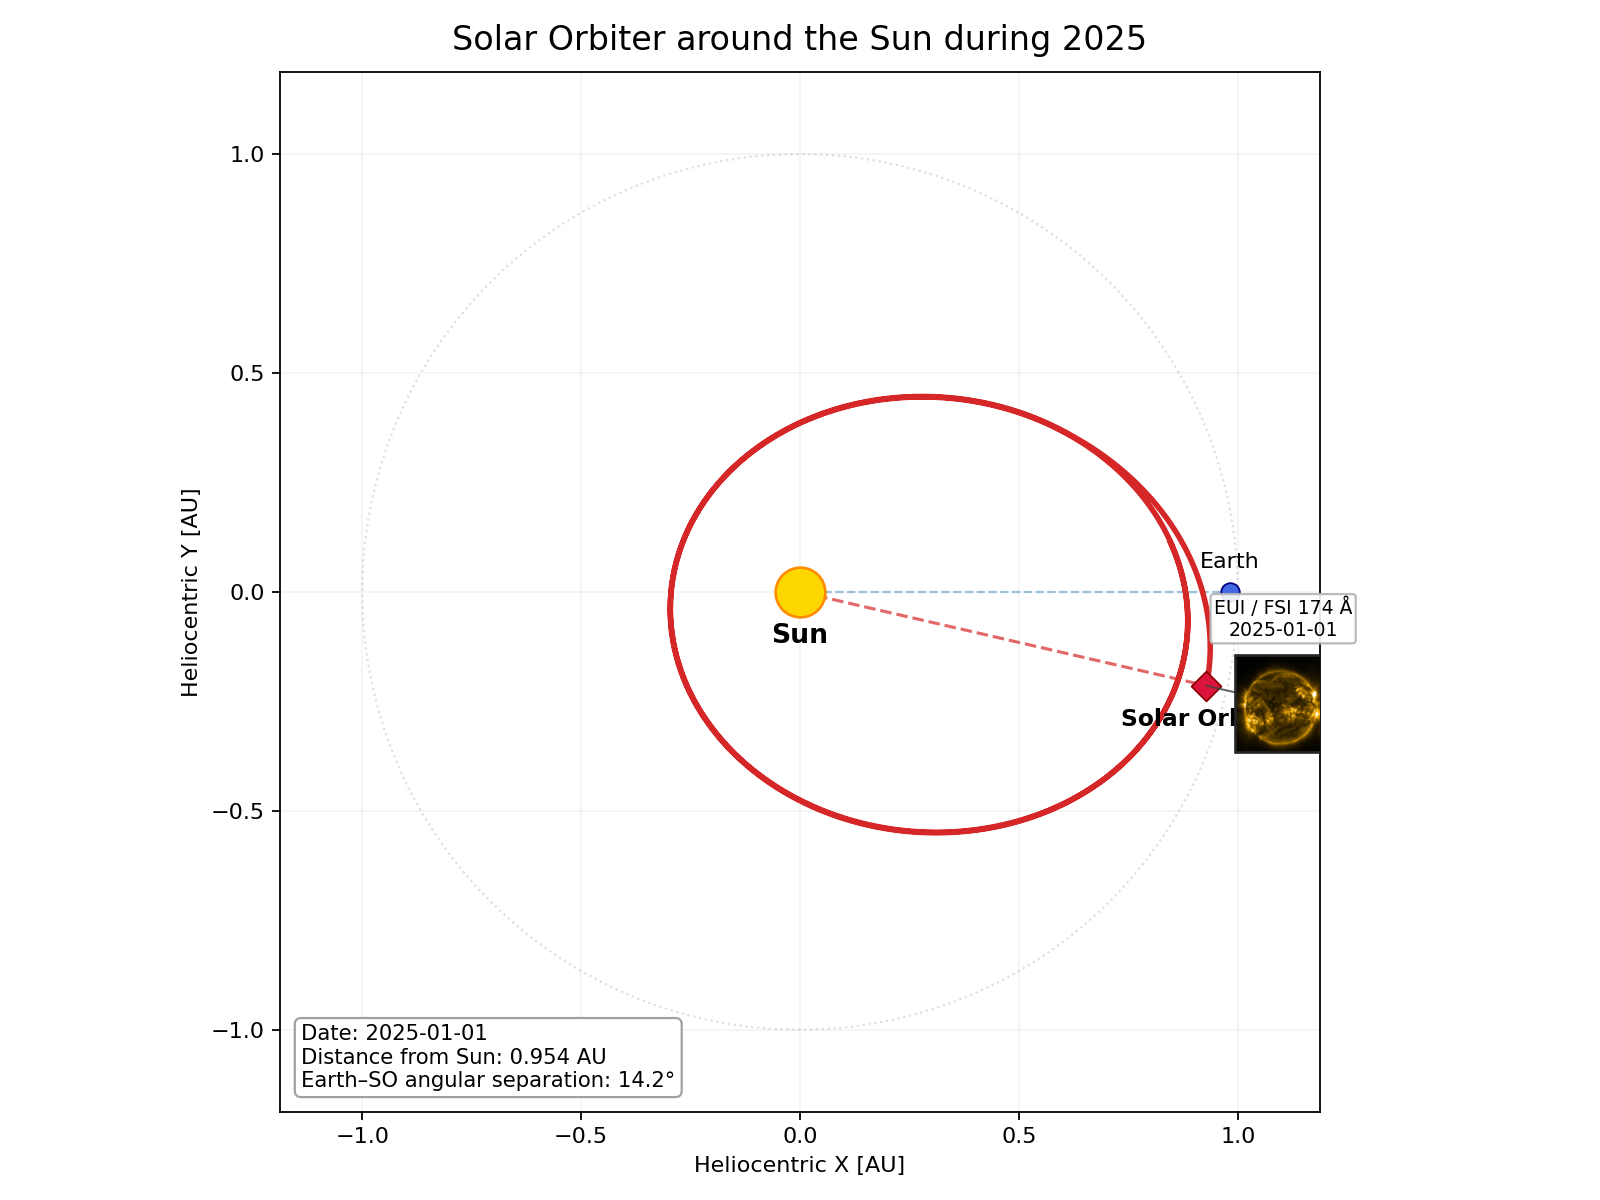

Last frame:


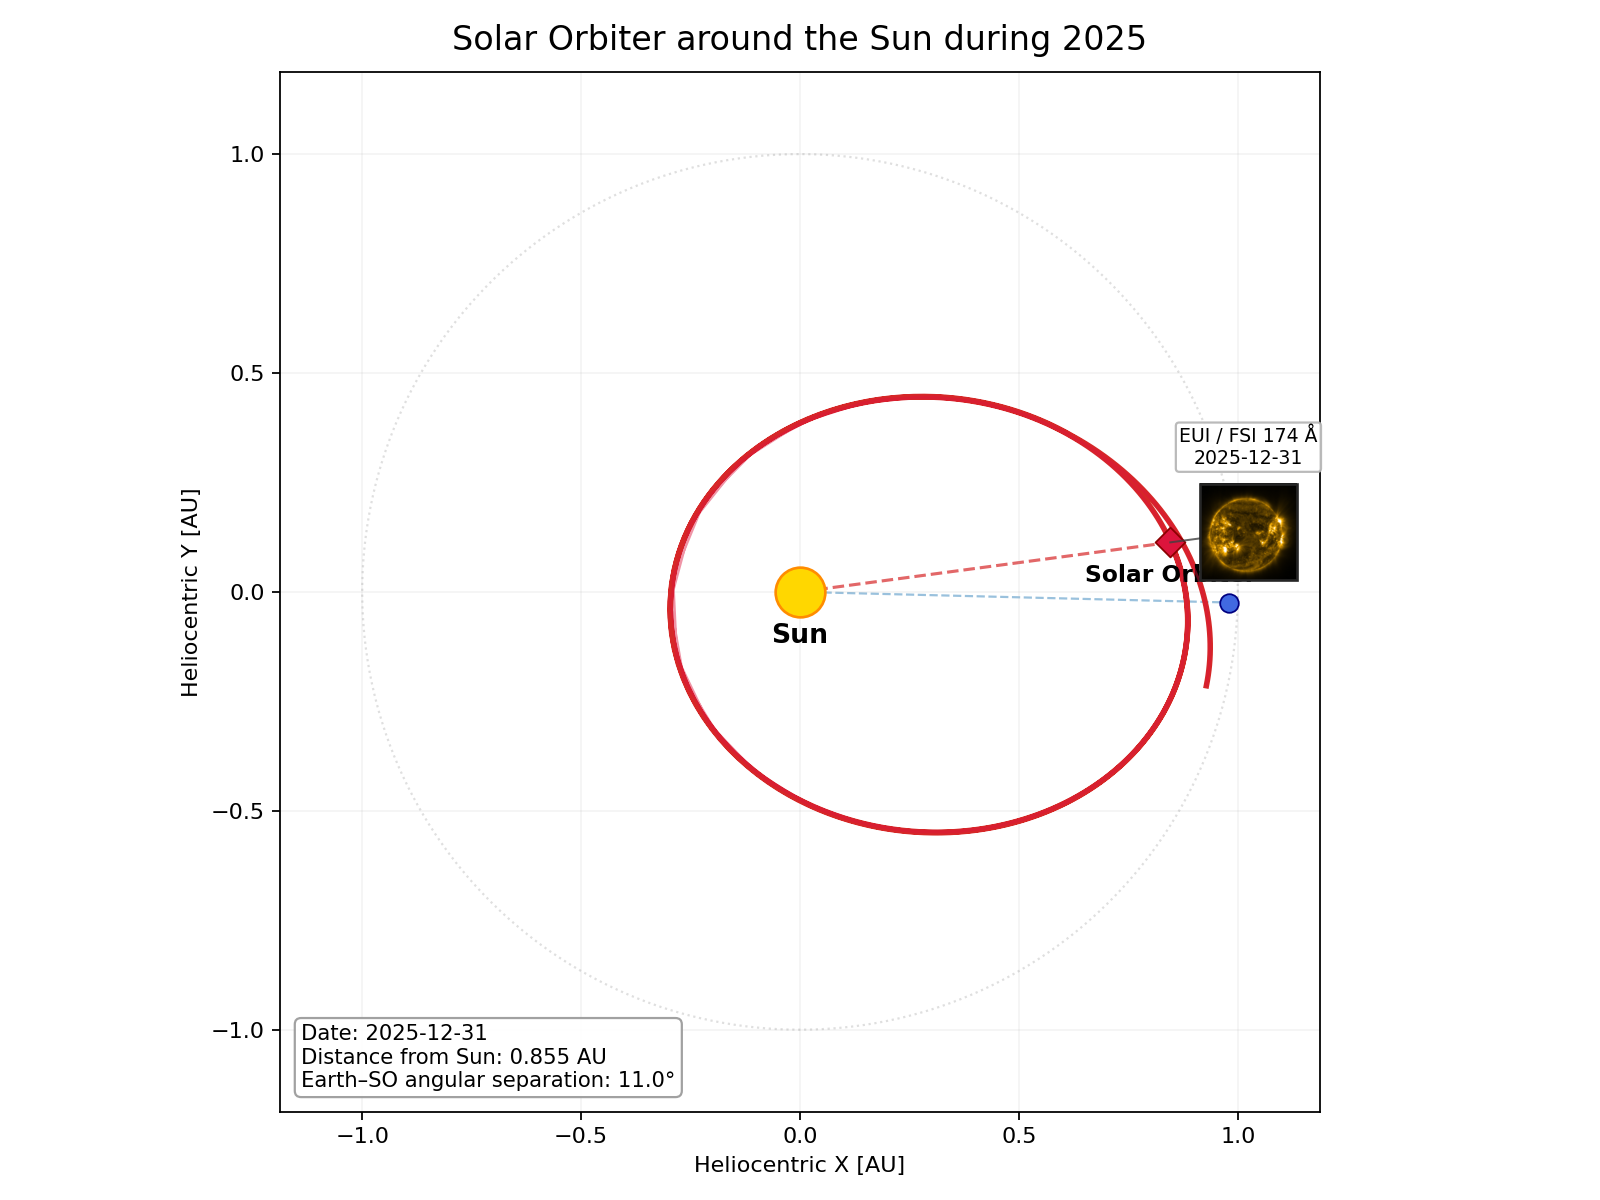

In [11]:
from IPython.display import Image, display

first_frame = sorted(frames_dir.glob("frame_*.png"))[0]
last_frame  = sorted(frames_dir.glob("frame_*.png"))[-1]

print("First frame:")
display(Image(filename=str(first_frame)))

print("Last frame:")
display(Image(filename=str(last_frame)))

## 10) الحفظ باللغة العربية

In [12]:
# ============================================================
# Create Arabic MP4 and GIF
# ============================================================

from pathlib import Path
import shutil
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from PIL import Image
import imageio.v2 as imageio

# ------------------------------------------------------------
# Arabic text support
# ------------------------------------------------------------
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "arabic-reshaper", "python-bidi"
    ])
    import arabic_reshaper
    from bidi.algorithm import get_display

def ar(text):
    return get_display(arabic_reshaper.reshape(text))

mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# Output names
# ------------------------------------------------------------
BASE_DIR = Path.cwd().resolve()

OUT_MP4_AR = Path(OUT_MP4).stem + "_ar.mp4"
OUT_GIF_AR = Path(OUT_GIF).stem + "_ar.gif"

out_mp4_ar = BASE_DIR / OUT_MP4_AR
out_gif_ar = BASE_DIR / OUT_GIF_AR

frames_dir_ar = BASE_DIR / "frames_solar_orbiter_video_ar"

if frames_dir_ar.exists():
    shutil.rmtree(frames_dir_ar)

frames_dir_ar.mkdir(parents=True, exist_ok=True)

print("Arabic frames directory:")
print(frames_dir_ar)

# ------------------------------------------------------------
# Plot limits
# ------------------------------------------------------------
tmp_x = list(np.asarray(x_orbit, dtype=float)) + [xy[0] for xy in frame_xy]
tmp_y = list(np.asarray(y_orbit, dtype=float)) + [xy[1] for xy in frame_xy]

LIM_AR = max(
    1.10,
    np.max(np.abs(tmp_x)) + 0.25,
    np.max(np.abs(tmp_y)) + 0.25
)

# ------------------------------------------------------------
# Angular separation
# ------------------------------------------------------------
def angular_separation_from_sun_ar(coord1, coord2):
    lon1 = coord1.lon.to_value(u.rad)
    lat1 = coord1.lat.to_value(u.rad)
    lon2 = coord2.lon.to_value(u.rad)
    lat2 = coord2.lat.to_value(u.rad)

    v1 = np.array([
        np.cos(lat1) * np.cos(lon1),
        np.cos(lat1) * np.sin(lon1),
        np.sin(lat1)
    ])

    v2 = np.array([
        np.cos(lat2) * np.cos(lon2),
        np.cos(lat2) * np.sin(lon2),
        np.sin(lat2)
    ])

    ang = np.degrees(
        np.arccos(
            np.clip(np.dot(v1, v2), -1.0, 1.0)
        )
    )

    return float(ang)

# ------------------------------------------------------------
# Draw one Arabic frame
# ------------------------------------------------------------
def draw_one_frame_ar(i):
    t = frame_times[i]
    xs, ys = frame_xy[i]
    xe, ye = earth_xy[i]

    sep = angular_separation_from_sun_ar(
        solo_frame_positions[i],
        earth_positions[i]
    )

    eui_key = frame_to_eui_key[i]
    eui_rgba = prepared_eui[eui_key]["rgba"]
    eui_label = prepared_eui[eui_key]["label"]

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    # 1 AU reference circle
    th = np.linspace(0, 2*np.pi, 500)
    ax.plot(
        np.cos(th), np.sin(th),
        ":",
        lw=1.0,
        alpha=0.25,
        color="0.5"
    )

    # Solar Orbiter orbit
    ax.plot(
        x_orbit, y_orbit,
        lw=2.5,
        color="tab:red",
        zorder=2
    )

    # Sun
    ax.scatter(
        [0], [0],
        s=500,
        color="gold",
        edgecolor="darkorange",
        lw=1.2,
        zorder=10
    )
    ax.text(
        0, -0.07,
        ar("الشمس"),
        ha="center",
        va="top",
        fontsize=12,
        weight="bold"
    )

    # Earth
    ax.scatter(
        [xe], [ye],
        s=70,
        color="royalblue",
        edgecolor="navy",
        lw=0.8,
        zorder=8
    )
    ax.text(
        xe, ye + 0.045,
        ar("الأرض"),
        ha="center",
        va="bottom",
        fontsize=10
    )

    # Sight lines
    ax.plot(
        [0, xs], [0, ys],
        "--",
        lw=1.4,
        color="tab:red",
        alpha=0.7,
        zorder=1
    )
    ax.plot(
        [0, xe], [0, ye],
        "--",
        lw=1.0,
        color="tab:blue",
        alpha=0.45,
        zorder=1
    )

    # Current Solar Orbiter position
    ax.scatter(
        [xs], [ys],
        s=90,
        marker="D",
        color="crimson",
        edgecolor="darkred",
        lw=0.8,
        zorder=12
    )
    ax.text(
        xs, ys - 0.05,
        ar("المركبة المدارية الشمسية"),
        ha="center",
        va="top",
        fontsize=10.5,
        weight="bold"
    )

    # Trail up to current frame
    trail_x = [frame_xy[j][0] for j in range(i + 1)]
    trail_y = [frame_xy[j][1] for j in range(i + 1)]
    ax.plot(
        trail_x, trail_y,
        lw=1.2,
        color="crimson",
        alpha=0.45,
        zorder=3
    )

    # --------------------------------------------------------
    # EUI inset location
    # --------------------------------------------------------
    rxy = np.hypot(xs, ys)
    if rxy > 0:
        ux = xs / rxy
        uy = ys / rxy
    else:
        ux, uy = 1.0, 0.0

    x0 = xs + INSET_OFFSET_AU * ux - INSET_SIZE_AU / 2
    x1 = xs + INSET_OFFSET_AU * ux + INSET_SIZE_AU / 2
    y0 = ys + INSET_OFFSET_AU * uy - INSET_SIZE_AU / 2
    y1 = ys + INSET_OFFSET_AU * uy + INSET_SIZE_AU / 2

    if eui_rgba is not None:
        ax.imshow(
            eui_rgba,
            origin="lower",
            extent=[x0, x1, y0, y1],
            interpolation="bilinear",
            zorder=20
        )

    rect = Rectangle(
        (x0, y0),
        INSET_SIZE_AU,
        INSET_SIZE_AU,
        fill=False,
        lw=1.2,
        ec="0.15",
        zorder=21
    )
    ax.add_patch(rect)

    ax.plot(
        [xs, (x0 + x1)/2],
        [ys, (y0 + y1)/2],
        "-",
        lw=0.9,
        color="0.25",
        alpha=0.8,
        zorder=18
    )

    # EUI label
    ax.text(
        (x0 + x1)/2,
        y1 + 0.035,
        "EUI / FSI 174 Å\n"
        + ar("تاريخ الرصد") + ": " + eui_label,
        ha="center",
        va="bottom",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.18",
            fc="white",
            ec="0.7",
            alpha=0.9
        ),
        zorder=22
    )

    # Info box
    r_au = solo_frame_positions[i].radius.to_value(u.AU)
    info_text = (
        ar("التاريخ") + f": {t.strftime('%Y-%m-%d')}\n"
        + ar("المسافة عن الشمس") + f": {r_au:.3f} " + ar("وحدة فلكية") + "\n"
        + ar("الفصل الزاوي بين الأرض والمركبة") + f": {sep:.1f}°"
    )

    ax.text(
        0.02, 0.02,
        info_text,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.30",
            fc="white",
            ec="0.6",
            alpha=0.92
        )
    )

    # Main title and axes
    ax.set_title(
        ar(f"مدار المركبة المدارية الشمسية حول الشمس خلال عام {YEAR}"),
        fontsize=15,
        pad=10
    )

    ax.set_xlabel(
        ar("الإحداثي X بالنسبة إلى الشمس [وحدة فلكية]")
    )
    ax.set_ylabel(
        ar("الإحداثي Y بالنسبة إلى الشمس [وحدة فلكية]")
    )

    ax.set_xlim(-LIM_AR, LIM_AR)
    ax.set_ylim(-LIM_AR, LIM_AR)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.15, lw=0.7)

    # Save frame
    out = frames_dir_ar / f"frame_ar_{i:03d}.png"
    fig.savefig(
        out,
        dpi=DPI,
        facecolor="white"
    )
    plt.close(fig)

    if not out.exists():
        raise RuntimeError(f"لم يتم حفظ الإطار: {out}")

    return out

# ============================================================
# Render Arabic frames
# ============================================================
print("بدء إنشاء الإطارات العربية...")

for i in range(len(frame_times)):
    if i % 5 == 0 or i == len(frame_times) - 1:
        print(f"الإطار {i+1}/{len(frame_times)}")
    draw_one_frame_ar(i)

frame_paths_ar = sorted(frames_dir_ar.glob("frame_ar_*.png"))

print("\nعدد الإطارات العربية:", len(frame_paths_ar))

if len(frame_paths_ar) != len(frame_times):
    raise RuntimeError(
        f"المتوقع {len(frame_times)} إطارًا، لكن الموجود {len(frame_paths_ar)}"
    )

# ============================================================
# Make all frames the same size
# ============================================================
sizes_ar = []
for fp in frame_paths_ar:
    with Image.open(fp) as im:
        sizes_ar.append(im.size)

def round_up_ar(value, multiple=16):
    return int(np.ceil(value / multiple) * multiple)

max_width_ar = max(w for w, h in sizes_ar)
max_height_ar = max(h for w, h in sizes_ar)

TARGET_WIDTH_AR = round_up_ar(max_width_ar, 16)
TARGET_HEIGHT_AR = round_up_ar(max_height_ar, 16)

print("حجم الفيديو العربي:", TARGET_WIDTH_AR, "x", TARGET_HEIGHT_AR)

def read_frame_ar(path):
    with Image.open(path) as im:
        im = im.convert("RGB")

        if im.width > TARGET_WIDTH_AR or im.height > TARGET_HEIGHT_AR:
            im.thumbnail((TARGET_WIDTH_AR, TARGET_HEIGHT_AR), Image.Resampling.LANCZOS)

        canvas = Image.new("RGB", (TARGET_WIDTH_AR, TARGET_HEIGHT_AR), "white")

        left = (TARGET_WIDTH_AR - im.width) // 2
        top = (TARGET_HEIGHT_AR - im.height) // 2

        canvas.paste(im, (left, top))
        return np.asarray(canvas)

# ============================================================
# Save Arabic MP4
# ============================================================
print("\nإنشاء MP4 العربي...")

with imageio.get_writer(
    str(out_mp4_ar),
    fps=FPS,
    codec="libx264",
    quality=8,
    macro_block_size=16,
    ffmpeg_params=[
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart"
    ],
) as writer:
    for i, fp in enumerate(frame_paths_ar):
        if i % 10 == 0 or i == len(frame_paths_ar) - 1:
            print(f"MP4: {i+1}/{len(frame_paths_ar)}")
        writer.append_data(read_frame_ar(fp))

print("تم حفظ MP4 العربي:")
print(out_mp4_ar)

# ============================================================
# Save Arabic GIF
# ============================================================
print("\nإنشاء GIF العربي...")

with imageio.get_writer(
    str(out_gif_ar),
    mode="I",
    fps=FPS,
    loop=0,
) as writer:
    for i, fp in enumerate(frame_paths_ar):
        if i % 10 == 0 or i == len(frame_paths_ar) - 1:
            print(f"GIF: {i+1}/{len(frame_paths_ar)}")
        writer.append_data(read_frame_ar(fp))

print("تم حفظ GIF العربي:")
print(out_gif_ar)

Arabic frames directory:
/Users/Amr/Downloads/مقالي/notebook/SO/SO/frames_solar_orbiter_video_ar
بدء إنشاء الإطارات العربية...
الإطار 1/74
الإطار 6/74
الإطار 11/74
الإطار 16/74
الإطار 21/74
الإطار 26/74
الإطار 31/74
الإطار 36/74
الإطار 41/74
الإطار 46/74
الإطار 51/74
الإطار 56/74
الإطار 61/74
الإطار 66/74
الإطار 71/74
الإطار 74/74

عدد الإطارات العربية: 74
حجم الفيديو العربي: 1600 x 1200

إنشاء MP4 العربي...
MP4: 1/74


[rawvideo @ 0x7faa1a717a80] Stream #0: not enough frames to estimate rate; consider increasing probesize
[vost#0:0/libx264 @ 0x7faa1b104780] Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


MP4: 11/74
MP4: 21/74
MP4: 31/74
MP4: 41/74
MP4: 51/74
MP4: 61/74
MP4: 71/74
MP4: 74/74
تم حفظ MP4 العربي:
/Users/Amr/Downloads/مقالي/notebook/SO/SO/Solar_Orbiter_2025_orbit_EUI_ar.mp4

إنشاء GIF العربي...
GIF: 1/74
GIF: 11/74
GIF: 21/74
GIF: 31/74
GIF: 41/74
GIF: 51/74
GIF: 61/74
GIF: 71/74
GIF: 74/74
تم حفظ GIF العربي:
/Users/Amr/Downloads/مقالي/notebook/SO/SO/Solar_Orbiter_2025_orbit_EUI_ar.gif
